<a href="https://colab.research.google.com/github/ZacharyMalonjao/finmark-customer-segmentation-dashboard/blob/main/finmark_data_mining_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import silhouette_score, calinski_harabasz_score #accuracy and permance metrics of the selected clustering algorithm
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN #clustering algorithms


In [73]:
feedback = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/FinMark-Machine-Learning/refs/heads/main/DMP/Customer_Feedback_Data.csv')
transaction = pd.read_csv('https://raw.githubusercontent.com/ZacharyMalonjao/FinMark-Machine-Learning/refs/heads/main/DMP/Transaction_Data.csv')

# Documentation

1. Feeback Table
* Customer_ID	-> Delete duplicates
* Satisfaction_Score-> no missing and outliers
* Feedback_Comments-> DELETED
* Likelihood_to_Recommend ->WINDSORIZATION, MEAN IMPUTATION

2. Documentation Table
* Transaction_ID-> no nulls, drop duplicates
* Customer_ID	-> drop nulls
* Transaction_Date-> delete column
* Transaction_Amount-> IQR, but kept outliers, Median Imputation and segmentantation
* Transaction_Type -> Ordinal Mapping

3. Feature Engineering
* Customer_ID -> 1 to 100
* Total_Transactions-> agregated Transaction_ID per customer
* Avg_Transaction_Amount-> Aggregated transaction amount (Mean, z-scored)
* Avg_Satisfaction_Score -> Agg satisfaction score (mean, z-scored)
* Avg_Likelihood_to_Recommend	-> agglikelihood to recommend (mean, z-scored)
* Mode_Transaction_Type->Mode of Transaction_Type
* Mode_Transaction_Amount_Segment-> Mode of Transaction_Amount segmentation
* Mode_Feedback_Comments-> Mode of feedback comments





#1. Clean Feedback table

## Customer ID

In [74]:
#Delete Duplicates

feedback['Customer_ID'].isna().sum()
duplicate_counts = feedback['Customer_ID'].value_counts()
duplicate_counts = duplicate_counts[duplicate_counts > 1]
print(duplicate_counts)


Customer_ID
37     13
959    12
106    11
509    11
280    11
       ..
187     2
210     2
136     2
122     2
194     2
Name: count, Length: 983, dtype: int64


In [75]:
# Keep first occurrence of each Customer_ID
feedback = feedback.drop_duplicates(subset='Customer_ID', keep='first')


In [76]:
duplicate_counts = feedback['Customer_ID'].value_counts()
duplicate_counts = duplicate_counts[duplicate_counts > 1]
print(duplicate_counts)


Series([], Name: count, dtype: int64)


## Satisfaction_Score and Likelihood_to_Recommend

Method:
* Median Imputation for Likelihood_to_recommend
* Satisfaction_score has no missing *and* outliers

In [77]:
print(feedback['Satisfaction_Score'].isna().sum() )
print(feedback['Likelihood_to_Recommend'].isna().sum())

22
0


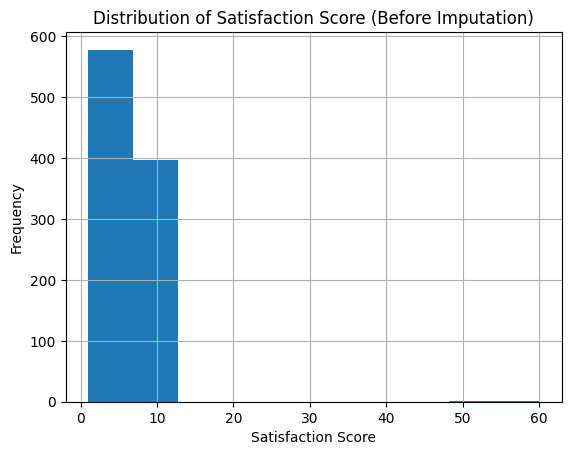

np.float64(6.3525779597795236)

In [78]:

#Check skewness of satisfaction score
feedback['Satisfaction_Score'].hist(bins=10)
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.title('Distribution of Satisfaction Score (Before Imputation)')
plt.show()
feedback['Satisfaction_Score'].skew()


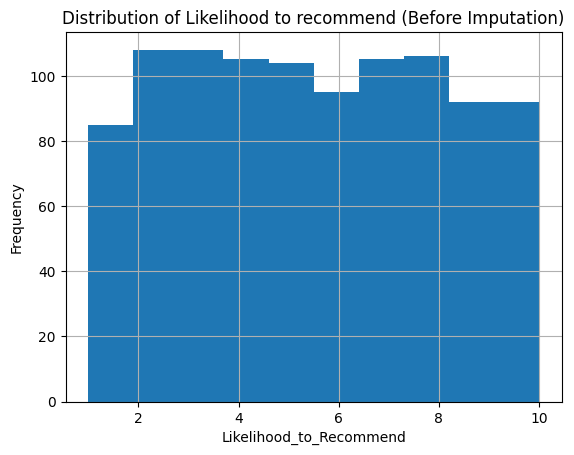

np.float64(0.032726976369705285)

In [79]:
#Skewness of likelihood to recommend

feedback['Likelihood_to_Recommend'].hist(bins=10)
plt.xlabel('Likelihood_to_Recommend')
plt.ylabel('Frequency')
plt.title('Distribution of Likelihood to recommend (Before Imputation)')
plt.show()
feedback['Likelihood_to_Recommend'].skew()

In [80]:
def check_outliers(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound= q1 - 1.5 * iqr
  upper_bound= q3 + 1.5 * iqr

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers


In [81]:
check_outliers(feedback, 'Likelihood_to_Recommend')
#Satisfaction score has no outliers, nor missing values


,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend


In [82]:
check_outliers(feedback, 'Satisfaction_Score')

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
529,530,52.0,Good service,10
573,574,60.0,Good service,9
857,858,56.0,Very satisfied,10


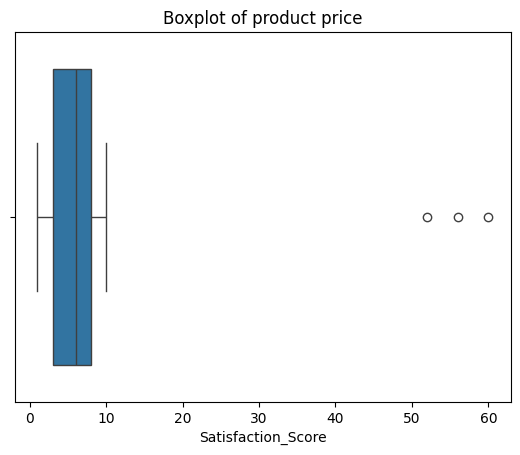

In [83]:
sns.boxplot(x=feedback['Satisfaction_Score'])
plt.title('Boxplot of product price')
plt.show()

In [84]:
# Impute missing values first
feedback['Satisfaction_Score'] = feedback['Satisfaction_Score'].fillna(
    feedback['Satisfaction_Score'].mean()
)

# Then winsorize
feedback['Satisfaction_Score'] = feedback['Satisfaction_Score'].clip(
    lower=1,
    upper=10
)
feedback['Satisfaction_Score'].isna().sum()


np.int64(0)

## 2. Clean Feedback_Comment

Method: Ordinal Integer Mapping

In [85]:
feedback=feedback.drop(columns='Feedback_Comments')
#Delete to remove duplication

# 2. Clean Transcation  

In [86]:
len(transaction)

5050

## 2.1 Transaction_ID

In [87]:
print(transaction['Transaction_ID'].isna().sum())


print(transaction['Transaction_ID'].duplicated().sum())
transaction = transaction.drop_duplicates(subset='Transaction_ID', keep = 'first')
print(transaction['Transaction_ID'].duplicated().sum())

0
50
0


## 2.2 Customer_ID

In [88]:
transaction = transaction.dropna(subset=['Customer_ID'])
valid_customers = set(feedback['Customer_ID'])
transaction = transaction[transaction['Customer_ID'].isin(valid_customers)]


##2.3 Transaction_Date


In [89]:
transaction=transaction.drop(columns=['Transaction_Date'])

## 2.4 Transaction_Amount

In [90]:
transaction['Transaction_Amount'].isna().sum()
(transaction['Transaction_Amount'] < 0).sum()


np.int64(0)

In [91]:
#Outliers (Keep them because it's normal in transaction data)

Q1 = transaction['Transaction_Amount'].quantile(0.25)
Q3 = transaction['Transaction_Amount'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 *IQR
upper_bound = Q3 + 1.5*IQR

outliers = (transaction['Transaction_Amount'] < lower_bound) | (transaction['Transaction_Amount'] > upper_bound)

print(transaction[outliers])

      Transaction_ID  Customer_ID  Transaction_Amount Transaction_Type
612              613          191            480300.0     Bill Payment
1264            1265          772            390200.0     Bill Payment
1738            1739           27            194500.0     Bill Payment
2045            2046           59            183500.0     Loan Payment
2184            2185          850             94500.0     Loan Payment
2270            2271          521            428900.0       Investment
3037            3038          690            458600.0     Bill Payment
3059            3060          195            270900.0       Investment
3289            3290          649            175600.0         Purchase
4852            4853          396            362700.0     Loan Payment


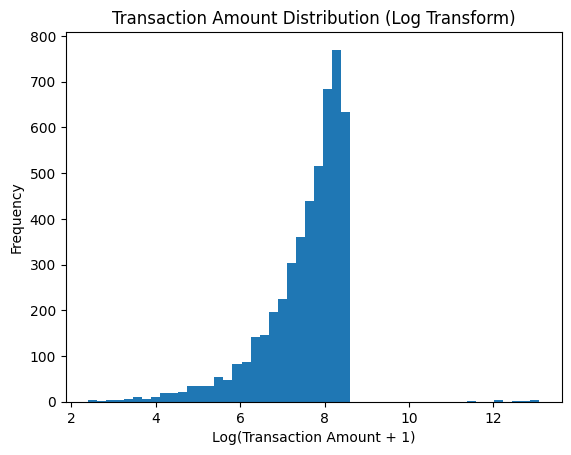

np.float64(26.13873535594198)

In [92]:
#Check Skew

plt.hist(np.log1p(transaction['Transaction_Amount']), bins=50)
plt.xlabel('Log(Transaction Amount + 1)')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution (Log Transform)')
plt.show()

transaction['Transaction_Amount'].skew()

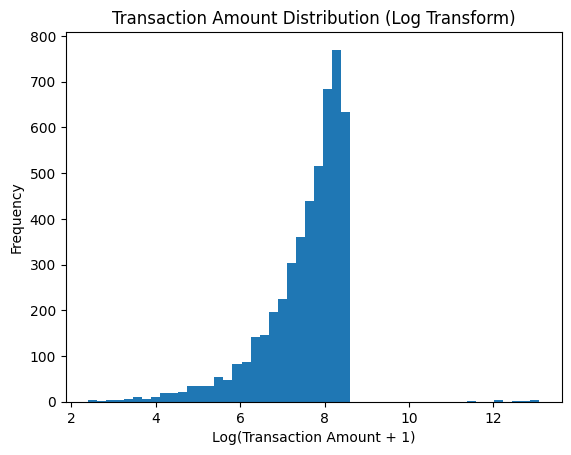

0


In [93]:

plt.hist(np.log1p(transaction['Transaction_Amount']), bins=50)
plt.xlabel('Log(Transaction Amount + 1)')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution (Log Transform)')
plt.show()
# Median imputation
median_amount = transaction['Transaction_Amount'].median()
transaction['Transaction_Amount'] = transaction['Transaction_Amount'].fillna(median_amount)
print(transaction['Transaction_Amount'].isna().sum())

In [94]:
# Create new column for segmentation
q1 = transaction['Transaction_Amount'].quantile(0.25)
q3 = transaction['Transaction_Amount'].quantile(0.75)
def segment(amount):
  if amount <=q1:
	  return 0
  elif amount <=q3:
    return 1
  else:
	  return 2
transaction['Transaction_Amount_Segment'] = transaction['Transaction_Amount'].apply(segment)

In [95]:
transaction['Transaction_Amount_Segment'].value_counts()


,count
Transaction_Amount_Segment,
1,2501
0,1251
2,1248


## 2.5 Transaction_Type


In [96]:
transaction['Transaction_Type'].astype(str).unique()

array(['Purchase', 'Bill Payment', 'Investment', 'Loan Payment'],
      dtype=object)

In [97]:


mapping = {
    'Purchase': 0,
    'Bill Payment': 1,
    'Investment': 2,
    'Loan Payment': 3
}


transaction['Transaction_Type'] = transaction['Transaction_Type'].map(mapping).astype(str)



In [98]:
transaction.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Amount_Segment
0,1,393,3472.0,0,1
1,2,826,2481.5,1,1
2,3,916,10.0,0,0
3,4,109,72.0,2,0
4,5,889,1793.0,2,1


# 3: Merge Tables

In [99]:
df = transaction.merge(
    feedback,
    how='left',
    on='Customer_ID'
)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              5000 non-null   int64  
 1   Customer_ID                 5000 non-null   int64  
 2   Transaction_Amount          5000 non-null   float64
 3   Transaction_Type            5000 non-null   object 
 4   Transaction_Amount_Segment  5000 non-null   int64  
 5   Satisfaction_Score          5000 non-null   float64
 6   Likelihood_to_Recommend     5000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 273.6+ KB


## 3.1 z Scores


In [101]:
df.head(20)

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Amount_Segment,Satisfaction_Score,Likelihood_to_Recommend
0,1,393,3472.0,0,1,1.000000,3
1,2,826,2481.5,1,1,5.654397,3
2,3,916,10.0,0,0,6.000000,3
3,4,109,72.0,2,0,3.000000,9
4,5,889,1793.0,2,1,8.000000,3
5,6,348,3824.0,3,2,5.654397,8
6,7,50,235.0,3,0,6.000000,4
7,8,916,1052.0,3,0,6.000000,3
8,9,105,854.0,0,0,8.000000,4
9,10,420,2690.0,2,1,5.000000,8


In [102]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Amount_Segment,Satisfaction_Score,Likelihood_to_Recommend
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,505.295400,3089.639800,0.999400,5.554335,5.447200
std,1443.520003,291.844284,14743.714207,0.707036,2.774545,2.812756
min,1.000000,1.000000,10.000000,0.000000,1.000000,1.000000
25%,1250.750000,252.000000,1260.000000,0.000000,3.000000,3.000000
50%,2500.500000,509.000000,2481.500000,1.000000,5.654397,5.000000
75%,3750.250000,765.250000,3682.000000,1.000000,8.000000,8.000000
max,5000.000000,1000.000000,480300.000000,2.000000,10.000000,10.000000


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              5000 non-null   int64  
 1   Customer_ID                 5000 non-null   int64  
 2   Transaction_Amount          5000 non-null   float64
 3   Transaction_Type            5000 non-null   object 
 4   Transaction_Amount_Segment  5000 non-null   int64  
 5   Satisfaction_Score          5000 non-null   float64
 6   Likelihood_to_Recommend     5000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 273.6+ KB


# 4. Feature Engineering


In [104]:
# Create a mode method
def mode_or_nan(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else np.nan


In [105]:
#Remove trailing
transaction.columns = transaction.columns.str.strip()


In [106]:
def mode_or_nan(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else np.nan

customer_data = (
    df
    .groupby('Customer_ID')
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),

        Avg_Transaction_Amount=('Transaction_Amount', 'mean'),
        Avg_Satisfaction_Score=('Satisfaction_Score', 'mean'),
        Avg_Likelihood_to_Recommend=('Likelihood_to_Recommend','mean'),

        Mode_Transaction_Type=('Transaction_Type', mode_or_nan),
        Mode_Transaction_Amount_Segment=('Transaction_Amount_Segment', mode_or_nan)
    )
    .reset_index()
)


In [107]:
#Create an instance for tableau-ready data

tableau_data = customer_data.copy()

In [108]:
scaler = StandardScaler()

num_cols=['Avg_Satisfaction_Score','Avg_Likelihood_to_Recommend', 'Avg_Transaction_Amount' ]
customer_data[num_cols]= scaler.fit_transform(customer_data[num_cols])

In [109]:
customer_data.head()

,Customer_ID,Total_Transactions,Avg_Transaction_Amount,Avg_Satisfaction_Score,Avg_Likelihood_to_Recommend,Mode_Transaction_Type,Mode_Transaction_Amount_Segment
0,1,6,-0.036276,1.614596,1.262792,1,2
1,2,2,-0.088484,-0.908231,-0.875234,1,1
2,3,1,-0.224076,1.614596,-1.587909,1,1
3,4,2,0.162410,0.533384,-0.518896,0,1
4,5,5,-0.013527,0.893788,0.550116,0,1


In [110]:
customer_data.isna().sum()

,0
Customer_ID,0
Total_Transactions,0
Avg_Transaction_Amount,0
Avg_Satisfaction_Score,0
Avg_Likelihood_to_Recommend,0
Mode_Transaction_Type,0
Mode_Transaction_Amount_Segment,0


In [111]:
customer_data.dtypes

,0
Customer_ID,int64
Total_Transactions,int64
Avg_Transaction_Amount,float64
Avg_Satisfaction_Score,float64
Avg_Likelihood_to_Recommend,float64
Mode_Transaction_Type,object
Mode_Transaction_Amount_Segment,int64


In [112]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_ID                      993 non-null    int64  
 1   Total_Transactions               993 non-null    int64  
 2   Avg_Transaction_Amount           993 non-null    float64
 3   Avg_Satisfaction_Score           993 non-null    float64
 4   Avg_Likelihood_to_Recommend      993 non-null    float64
 5   Mode_Transaction_Type            993 non-null    object 
 6   Mode_Transaction_Amount_Segment  993 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 54.4+ KB


# 5. EDA

## Reference for readability
Transaction Type:

* 'Purchase': 0,
* 'Bill Payment': 1,
* 'Investment': 2,
* 'Loan Payment': 3

Transaction Amount
* 0: low
* 1: medium
* 2: High


In [113]:
customer_data.dtypes

,0
Customer_ID,int64
Total_Transactions,int64
Avg_Transaction_Amount,float64
Avg_Satisfaction_Score,float64
Avg_Likelihood_to_Recommend,float64
Mode_Transaction_Type,object
Mode_Transaction_Amount_Segment,int64


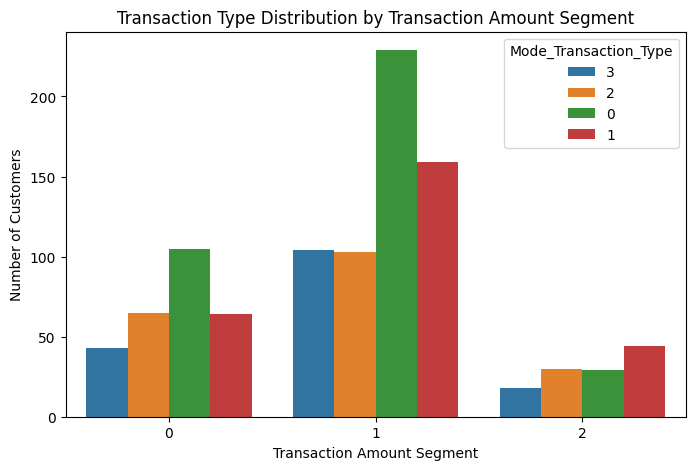

In [114]:
# Transaction amount vs transaction type


plt.figure(figsize=(8,5))
sns.countplot(data=customer_data,
              x='Mode_Transaction_Amount_Segment',
              hue='Mode_Transaction_Type')
plt.title("Transaction Type Distribution by Transaction Amount Segment")
plt.xlabel("Transaction Amount Segment")
plt.ylabel("Number of Customers")
plt.show()

In [115]:
# #Feedback by transaction amount (0=low satisfaction)

# plt.figure(figsize=(8,5))
# sns.countplot(data=customer_data,
#               x='Mode_Transaction_Amount_Segment',
#               hue='Mode_Feedback_Comments')
# plt.title("Feedback Distribution by Transaction Amount Segment")
# plt.xlabel("Transaction Amount Segment")
# plt.ylabel("Number of Customers")
# plt.show()

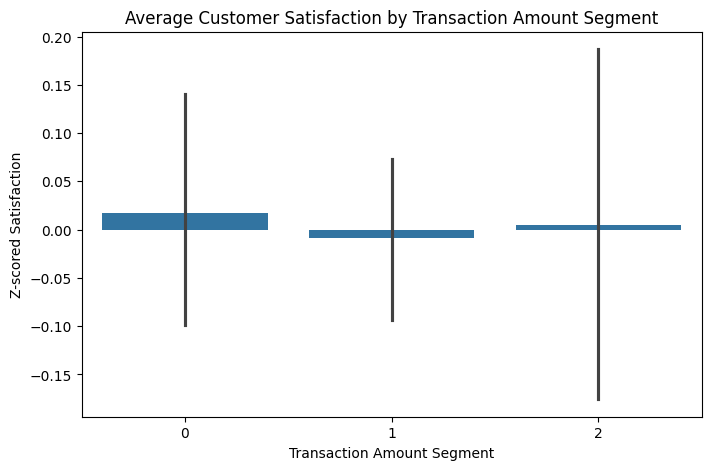

In [116]:
# Transaction amount vs satisfaction score
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=customer_data,
    x='Mode_Transaction_Amount_Segment',
    y='Avg_Satisfaction_Score'
)

plt.title("Average Customer Satisfaction by Transaction Amount Segment")
plt.xlabel("Transaction Amount Segment")
plt.ylabel("Z-scored Satisfaction")
plt.show()


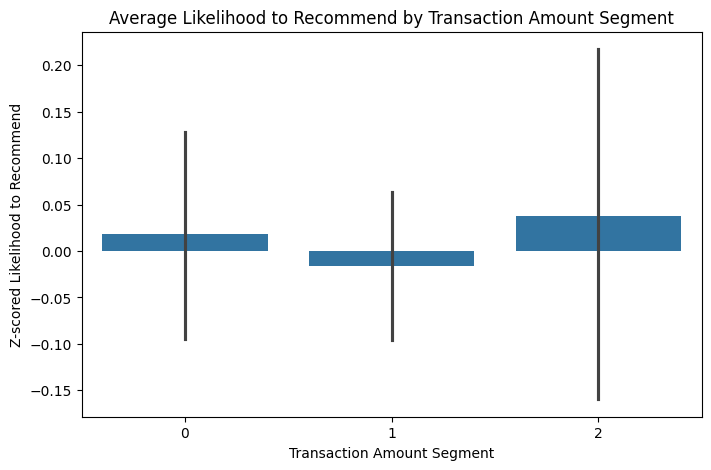

In [117]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=customer_data,
    x='Mode_Transaction_Amount_Segment',
    y='Avg_Likelihood_to_Recommend'
)

plt.title("Average Likelihood to Recommend by Transaction Amount Segment")
plt.xlabel("Transaction Amount Segment")
plt.ylabel("Z-scored Likelihood to Recommend")
plt.show()


# 6. PCA (MS2)


## 6a. Scaling/ Encoding


In [118]:
# Check code again
customer_data.dtypes

,0
Customer_ID,int64
Total_Transactions,int64
Avg_Transaction_Amount,float64
Avg_Satisfaction_Score,float64
Avg_Likelihood_to_Recommend,float64
Mode_Transaction_Type,object
Mode_Transaction_Amount_Segment,int64


In [119]:
# Scale and fit

#Drop not needed column
customer_data = customer_data.drop(columns=["Customer_ID", "Avg_Transaction_Amount"])

#Define Feature groups
numeric_features = [
    "Total_Transactions",
    "Avg_Satisfaction_Score",
    "Avg_Likelihood_to_Recommend",
    "Mode_Transaction_Amount_Segment"
]

categorical_features = [

    "Mode_Transaction_Type"
]


# Pre processor


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# Fit and transform
X = preprocessor.fit_transform(customer_data)
num_feature_names = numeric_features
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) + list(cat_feature_names)



## 6b. Dimensionality Reduction
We need to check how many variables are needed to preserve info, and the graph says 90%. We reduce it further to 2 variables, PC1 and PC2 from 4 variables out of 5.


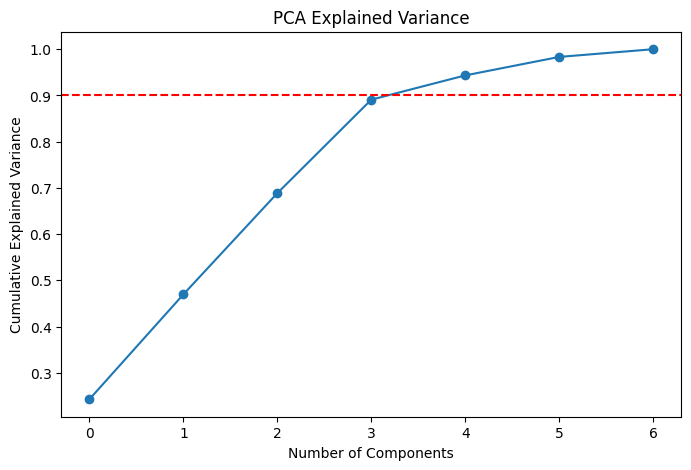

In [120]:
pca_full = PCA()
pca_full.fit(X)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.90, linestyle="--", color="red")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

#Funnel X into PCA and X_pca
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

In [121]:
# Create PCA scores DataFrame
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("\nFirst 5 PCA scores:\n")
print(pca_scores_df.head())



First 5 PCA scores:

        PC1       PC2
0  1.773298 -0.279961
1 -0.854115 -0.084344
2 -0.578909  2.142383
3 -0.653916  0.670616
4  0.260425  0.182699


##6c. PCA Loadings
We need to find out which 2 variables influence PC1 and 2 the most. From the code below we can se that:
* PC1 is Transaction Intensity Dimension
(How large and frequent customer transact)
* PC2 is Customer Sentiment CDimnesion
(How happy and loyal customers are)

In [122]:
#PCA Loadings (Feature Contributions)
# Get feature names from preprocessing
feature_names = all_feature_names  # from previous preprocessing step
# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names
)
print("\nPCA Loadings:\n")
print(loadings)


PCA Loadings:

                                      PC1       PC2
Total_Transactions               0.707844 -0.028736
Avg_Satisfaction_Score           0.202952  0.692919
Avg_Likelihood_to_Recommend     -0.122335 -0.653115
Mode_Transaction_Amount_Segment  0.662961 -0.303421
Mode_Transaction_Type_1          0.048787  0.011233
Mode_Transaction_Type_2         -0.022173 -0.016772
Mode_Transaction_Type_3          0.020335  0.002396


In [123]:
# Absolute loadings to identify strongest contributors
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(2)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(2)
print("\nTop 2 features contributing to PC1:")
print(top_pc1)
print("\nTop 2 features contributing to PC2:")
print(top_pc2)



Top 2 features contributing to PC1:
Total_Transactions                 0.707844
Mode_Transaction_Amount_Segment    0.662961
Name: PC1, dtype: float64

Top 2 features contributing to PC2:
Avg_Satisfaction_Score         0.692919
Avg_Likelihood_to_Recommend    0.653115
Name: PC2, dtype: float64


## 6d. K-Means on PCA
let's cluster in compressed behavioral space so that clusters are based on PC1 and PC2

In [124]:
# Run K-Means on PCA scores
from sklearn.cluster import KMeans

#Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_scores_df["KMeans_Cluster"] = kmeans.fit_predict(X_pca)
print("Silhouette Score:",
      silhouette_score(X_pca, pca_scores_df["KMeans_Cluster"]))
print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_pca, pca_scores_df["KMeans_Cluster"]))

Silhouette Score: 0.34109368529526496
Calinski-Harabasz Score: 655.1013385195511


## 6e. Biplot
Let's discover where the clusters lie and which features ush customers in a particular direction

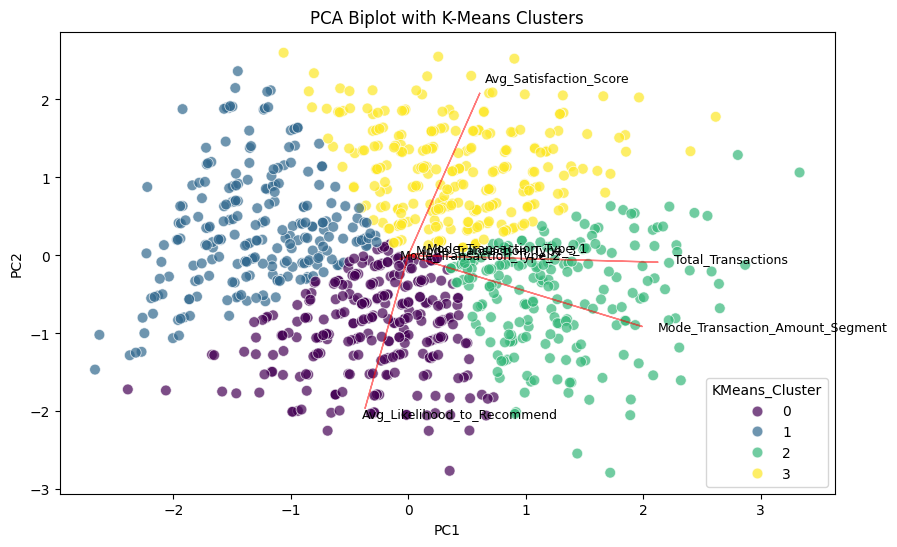

In [125]:
#Annotate Feature Directions on PCA Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    data=pca_scores_df,
    palette="viridis",
    s=60,
    alpha=0.7
)

# Plot feature vectors
for feature in loadings.index:
    plt.arrow(
        0, 0,
        loadings.loc[feature, "PC1"] * 3,
        loadings.loc[feature, "PC2"] * 3,
        color="red",
        alpha=0.5
    )
    plt.text(
        loadings.loc[feature, "PC1"] * 3.2,
        loadings.loc[feature, "PC2"] * 3.2,
        feature,
        fontsize=9
    )

plt.title("PCA Biplot with K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [126]:
# Combine PCA clusters with original customer data
clustered_customers = customer_data.copy()
clustered_customers["Cluster"] = pca_scores_df["KMeans_Cluster"]

# Look at average stats per cluster
clustered_customers.groupby("Cluster").mean(numeric_only=True)



,Total_Transactions,Avg_Satisfaction_Score,Avg_Likelihood_to_Recommend,Mode_Transaction_Amount_Segment
Cluster,,,,
0,4.470175,-0.663387,0.623885,0.950877
1,3.260870,-0.034517,-0.006080,0.195652
2,7.239024,-0.090316,0.186826,1.400000
3,5.465201,0.789447,-0.786476,0.857143


## 6f. Elbow Method
We check the elbow for the number of clusters we can implement, and the steepness of the curve stops at around 3 and 4, so this justifies using k=4


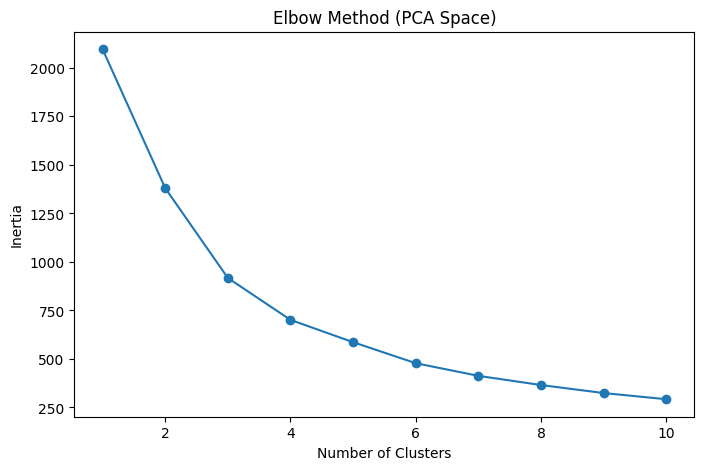

In [127]:
#K Means CLustering


#Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method (PCA Space)")
plt.show()

## 6g. Apply K Means
The moment we've all been waiting for. Explanation is below the graph.

In [128]:
#Apply K-Means
kmeans = KMeans(n_clusters=4,n_init=10)
pca_scores_df["KMeans_Cluster"] = kmeans.fit_predict(X_pca)
print("Silhouette Score:",
      silhouette_score(X_pca, pca_scores_df["KMeans_Cluster"]))
print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_pca, pca_scores_df["KMeans_Cluster"]))

Silhouette Score: 0.34109368529526496
Calinski-Harabasz Score: 655.101338519551


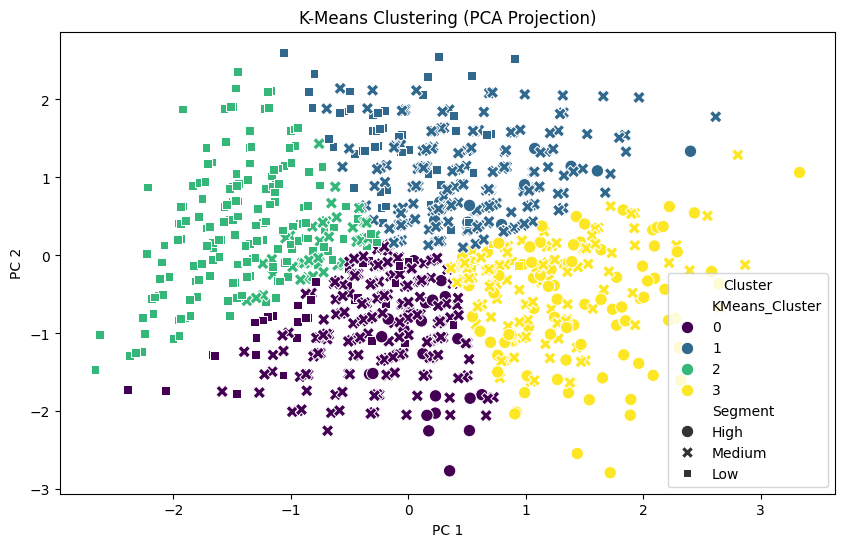

In [129]:
#Adding original segmentation column back

segment_labels = {0: "Low", 1: "Medium", 2: "High"}

pca_scores_df["Segment"] = customer_data["Mode_Transaction_Amount_Segment"].map(segment_labels)



# PCA Cluster Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    style="Segment",
    data=pca_scores_df,
    palette="viridis",
    s=80
)
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Cluster")
plt.show()

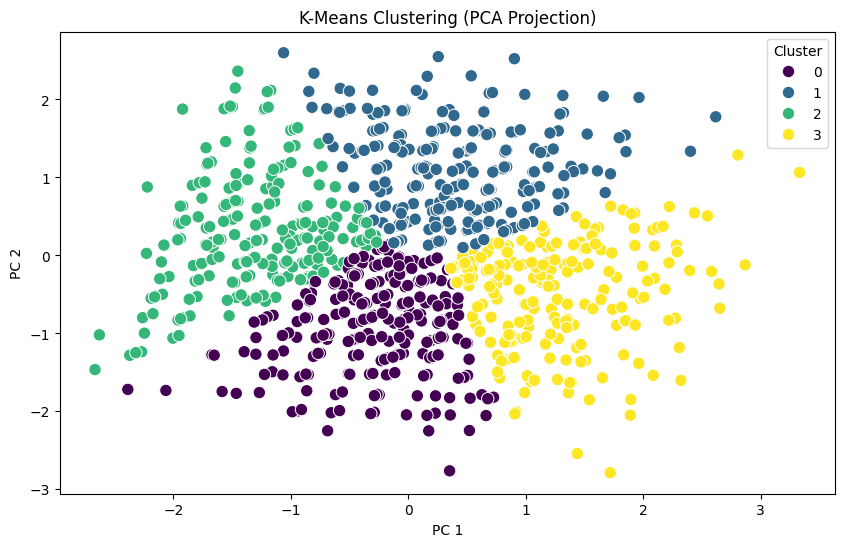

In [130]:
#Simplified version of the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    #style="Segment",
    data=pca_scores_df,
    palette="viridis",
    s=80
)
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Cluster")
plt.show()

Color interpretations:
* Purple = Low intensity, low satisfaction customers (Disappointed Casuals)
* Blue = Low intensity, high satisfaction customers (Happy casual customers)
* Yellow = Medium intensity, high satisfaction(Loyal customers)
* Green = High intensity, mid-to-low satisfaction (heavy spenders that aren't satisfied but not disappointed)



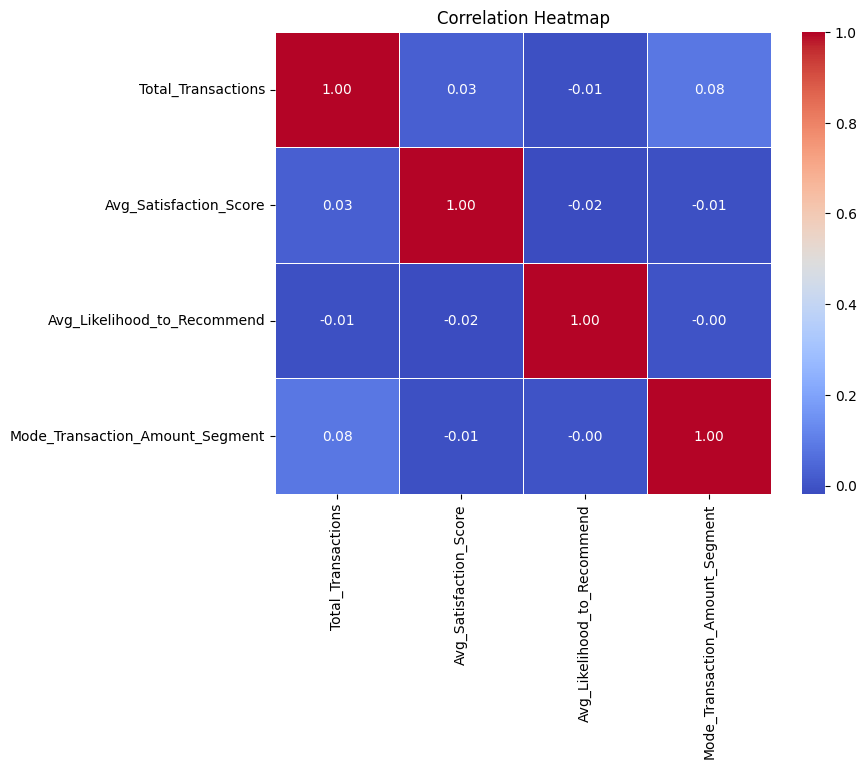

In [131]:
numeric_df = customer_data.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers
    cmap="coolwarm",     # color scheme
    fmt=".2f",           # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# 7. Prepare Data for Tableau Visualization

In [132]:
tableau_data.head()

,Customer_ID,Total_Transactions,Avg_Transaction_Amount,Avg_Satisfaction_Score,Avg_Likelihood_to_Recommend,Mode_Transaction_Type,Mode_Transaction_Amount_Segment
0,1,6,2806.0,10.0,9.0,1,2
1,2,2,2453.5,3.0,3.0,1,1
2,3,1,1538.0,10.0,1.0,1,1
3,4,2,4147.5,7.0,4.0,0,1
4,5,5,2959.6,8.0,7.0,0,1


## Return the Ordinal mappings

In [133]:
tableau_data['Mode_Transaction_Type'] = tableau_data['Mode_Transaction_Type'].map({
    '0': 'Purchase',
    '1': 'Bill Payment',
    '2': 'Investment',
    '3': 'Loan Payment'
})

In [134]:
tableau_data['Mode_Transaction_Type'].unique()


array(['Bill Payment', 'Purchase', 'Loan Payment', 'Investment'],
      dtype=object)

In [135]:
tableau_data['Mode_Transaction_Amount_Segment'] = tableau_data['Mode_Transaction_Amount_Segment'].map({
    0: 'Low Transaction Amount',
    1: 'Medium Transaction Amount',
    2: 'High Transaction Amount'

})

In [136]:
#Attach the kmeans anad PCA scores to the dtataset

# Add PCA coordinates and K-Means cluster to Tableau dataset
tableau_data["PC1"] = pca_scores_df["PC1"].values
tableau_data["PC2"] = pca_scores_df["PC2"].values
tableau_data["KMeans_Cluster"] = pca_scores_df["KMeans_Cluster"].values

cluster_labels = {
    0: "High-Engagement / Positive Sentiment",
    1: "Low-Engagement / Positive Sentiment",
    2: "High-Engagement / Negative Sentiment",
    3: "Low-Engagement / Negative Sentiment"
}

tableau_data["Customer_Segment"] = tableau_data["KMeans_Cluster"].map(cluster_labels)


In [137]:
#Sanity checks
print(tableau_data.shape)
print(tableau_data.dtypes)
print(tableau_data.isnull().sum())
print(tableau_data['KMeans_Cluster'].value_counts().sort_index())
print(tableau_data['Customer_Segment'].value_counts())

(993, 11)
Customer_ID                          int64
Total_Transactions                   int64
Avg_Transaction_Amount             float64
Avg_Satisfaction_Score             float64
Avg_Likelihood_to_Recommend        float64
Mode_Transaction_Type               object
Mode_Transaction_Amount_Segment     object
PC1                                float64
PC2                                float64
KMeans_Cluster                       int32
Customer_Segment                    object
dtype: object
Customer_ID                        0
Total_Transactions                 0
Avg_Transaction_Amount             0
Avg_Satisfaction_Score             0
Avg_Likelihood_to_Recommend        0
Mode_Transaction_Type              0
Mode_Transaction_Amount_Segment    0
PC1                                0
PC2                                0
KMeans_Cluster                     0
Customer_Segment                   0
dtype: int64
KMeans_Cluster
0    285
1    273
2    230
3    205
Name: count, dtype: int64
Custom

In [140]:
customer_data.to_csv("machine_learning_data.csv", index=False)

In [141]:
from google.colab import files
files.download('machine_learning_data.csv')  # match your actual filename/path


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>